# Final Project
### In my final project, I used data from the CLOUPE Browser to gather cervical cancer cells from one patient and analyze the gene expression through several different methods. I first created volcano plots of six different clusters to analyze. Then, I trained a neural network to see if my model could correctly input the cells into the corresponding cluster. I chose two different regions in my UMAP visualization from CLOUPE to compare and contrast them.

## AI Use
### I used AI for my PCA plot code because I wanted to know how to label the top 20 genes of each cluster. I also got AI help to print the top 20 genes into a table. Additionally, I also got help from classmates and my friend in the CS department. My CS friend helped me fix up the code for my neural network, my confusion matrix, and gene table. Other than that, I used previous labs or searched on Google for simple codes like changing the directory. 

In [1]:
# Import all packages
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy import stats
import statsmodels.stats.multitest as smm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

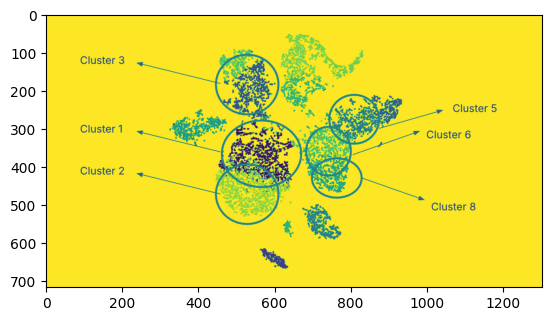

In [7]:
# Import all the programming libraries we will need for this notebook.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np
import cv2

# Define img to be our photo imported into this notebook. Then use the plotting library 
# ('plt.COMMAND') to plot the image
img = cv2.imread('CloupeData.jpg', 0)
plt.imshow(img)
plt.show()

In [89]:
# Make sure we are in the correct directory. All of my volcano plots were failing and Mikayla helped me to realize that all of my files needed to be in the same folder.
!unzip -o "/content/csv files (1).zip" -d "/content/csv_files_extracted"
%cd "/content/csv_files_extracted"

Archive:  /content/csv files (1).zip
  inflating: /content/csv_files_extracted/__MACOSX/._csv files  
  inflating: /content/csv_files_extracted/csv files/cluster 8.csv  
  inflating: /content/csv_files_extracted/__MACOSX/csv files/._cluster 8.csv  
  inflating: /content/csv_files_extracted/csv files/cluster 1.csv  
  inflating: /content/csv_files_extracted/__MACOSX/csv files/._cluster 1.csv  
  inflating: /content/csv_files_extracted/csv files/cluster 3.csv  
  inflating: /content/csv_files_extracted/__MACOSX/csv files/._cluster 3.csv  
  inflating: /content/csv_files_extracted/csv files/cluster 2.csv  
  inflating: /content/csv_files_extracted/__MACOSX/csv files/._cluster 2.csv  
  inflating: /content/csv_files_extracted/csv files/cluster 6.csv  
  inflating: /content/csv_files_extracted/__MACOSX/csv files/._cluster 6.csv  
  inflating: /content/csv_files_extracted/csv files/cluster 5.csv  
  inflating: /content/csv_files_extracted/__MACOSX/csv files/._cluster 5.csv  
  inflating: /co

In [90]:
pwd

'/content/csv_files_extracted'

In [65]:
# Create a definition to make plotting volcano plots much simpler. This was from lab 7, I had many issues but Mikayla helped me start this.

def create_volcanoplot(csv_file, gene_column="FeatureName", title="Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), highlight_color='red', annotate_top_n=40, ax=None):

    df = pd.read_csv(csv_file)

    if gene_column is not None and gene_column in df.columns:
        gene_names = df[gene_column].values
        df = df.drop(columns=[gene_column])
    else:
        gene_names = df.index.astype(str)

    log2_fold_changes = df["Log2 Fold Change"].values
    p_values = df["P-Value"].values

    p_values = np.nan_to_num(p_values, nan=1.0)
    neg_log_p = -np.log10(p_values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.scatter(log2_fold_changes, neg_log_p,
               alpha=0.5, color='gray', s=30)

    significant = (abs(log2_fold_changes) > log2_fc_threshold) & (p_values < p_threshold)

    upregulated = significant & (log2_fold_changes > 0)
    downregulated = significant & (log2_fold_changes < 0)

# plot non-significant (gray)
    ax.scatter(log2_fold_changes[~significant],
           neg_log_p[~significant],
           alpha=0.5, color='gray', s=30)

# plot the upregulated (red)
    ax.scatter(log2_fold_changes[upregulated],
           neg_log_p[upregulated],
           color='red', s=30, label='Upregulated')

# plot the downregulated (blue)
    ax.scatter(log2_fold_changes[downregulated],
           neg_log_p[downregulated],
           color='blue', s=30, label='Downregulated')

    ax.axhline(y=-np.log10(p_threshold), color='blue', linestyle='--', alpha=0.3)
    ax.axvline(x=log2_fc_threshold, color='blue', linestyle='--', alpha=0.3)
    ax.axvline(x=-log2_fc_threshold, color='blue', linestyle='--', alpha=0.3)

    ax.set_xlabel("Log2 Fold Change")
    ax.set_ylabel("-Log10 P-value")
    ax.set_title(title)

    if annotate_top_n > 0:
        top_indices = np.argsort(neg_log_p)[-annotate_top_n:]

        for i in top_indices:
            if significant[i]:
                ax.annotate(gene_names[i],
                            (log2_fold_changes[i], neg_log_p[i]),
                            xytext=(5, 5),
                            textcoords='offset points',
                            fontsize=8)

    ax.grid(alpha=0.3)


    return fig, ax

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 1 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

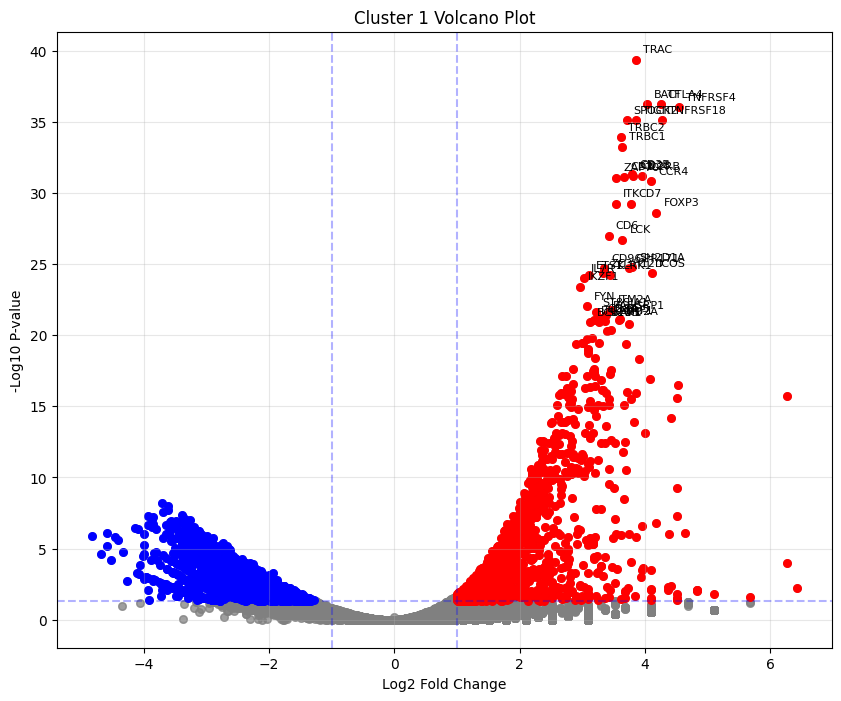

In [59]:
# Plot Each Cluster. Clusters 1,2,3 are in one region, while clusters 5,6,8 are in another.
create_volcanoplot('csv files/cluster 1.csv', gene_column="FeatureName", title="Cluster 1 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 2 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

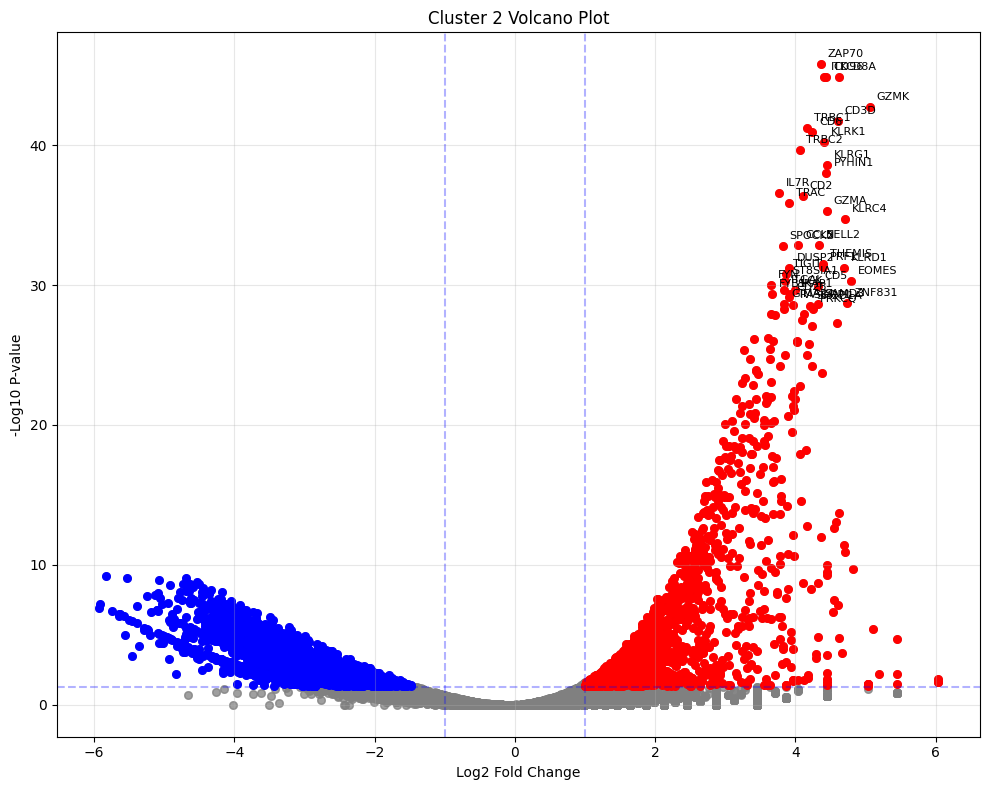

In [9]:
create_volcanoplot('csv files/cluster 2.csv', gene_column="FeatureName", title="Cluster 2 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 3 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

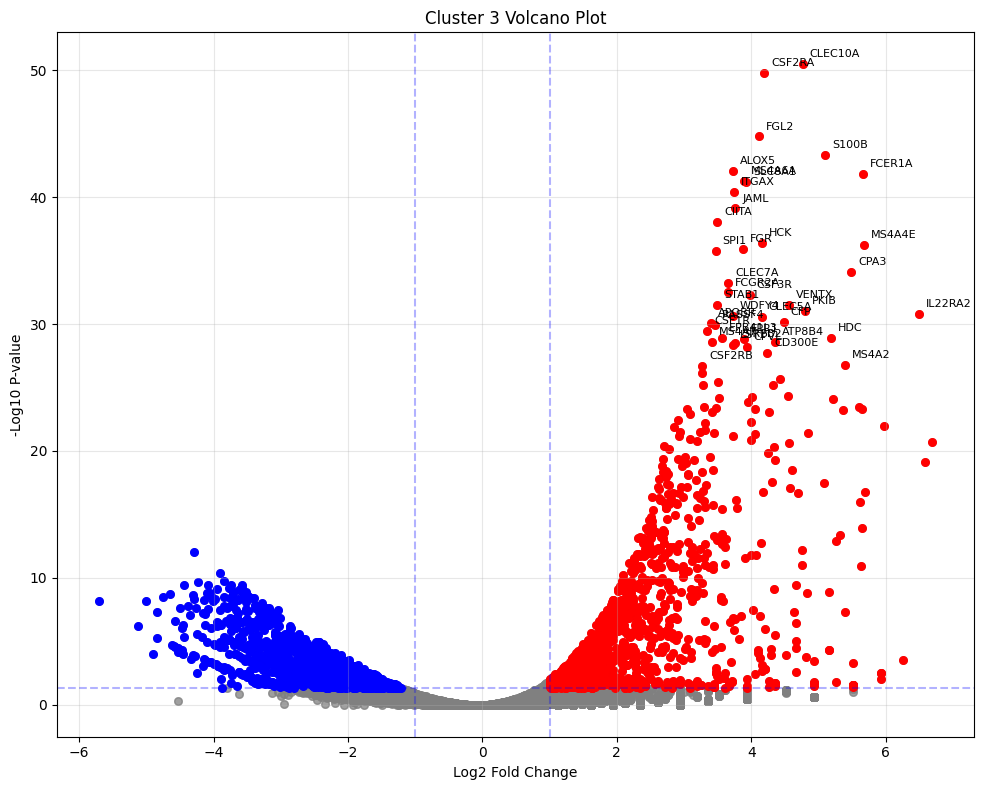

In [10]:
create_volcanoplot('csv files/cluster 3.csv', gene_column="FeatureName", title="Cluster 3 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 5 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

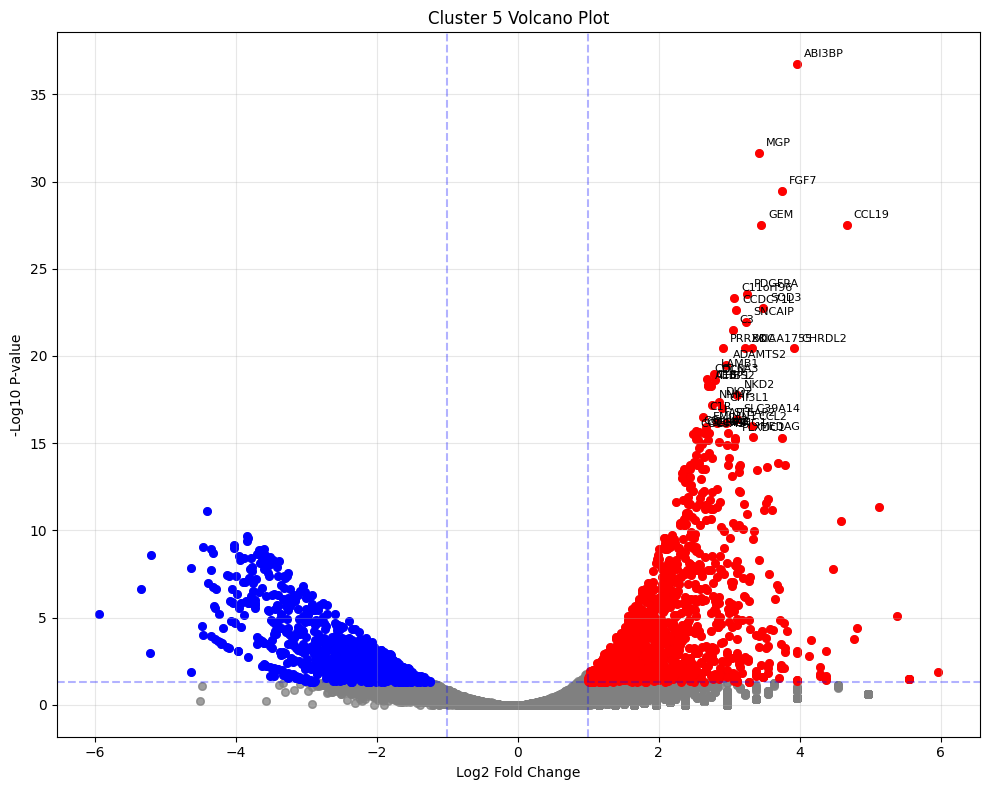

In [11]:
create_volcanoplot('csv files/cluster 5.csv', gene_column="FeatureName", title="Cluster 5 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 6 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

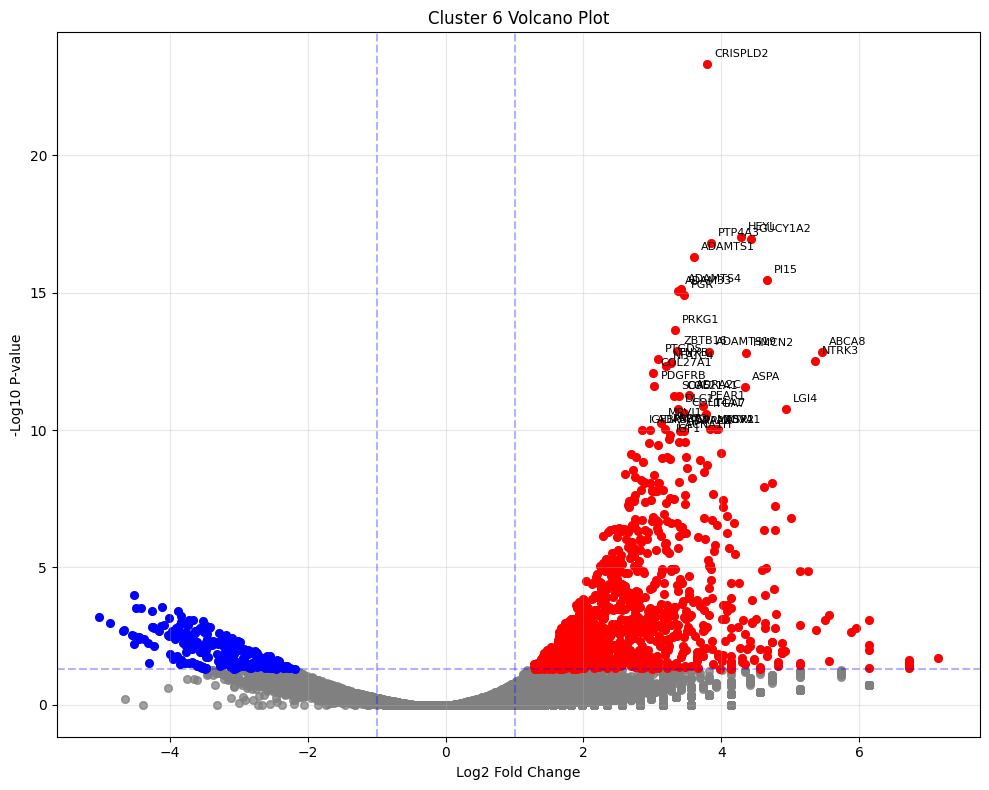

In [12]:
create_volcanoplot('csv files/cluster 6.csv', gene_column="FeatureName", title="Cluster 6 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Cluster 8 Volcano Plot'}, xlabel='Log2 Fold Change', ylabel='-Log10 P-value'>)

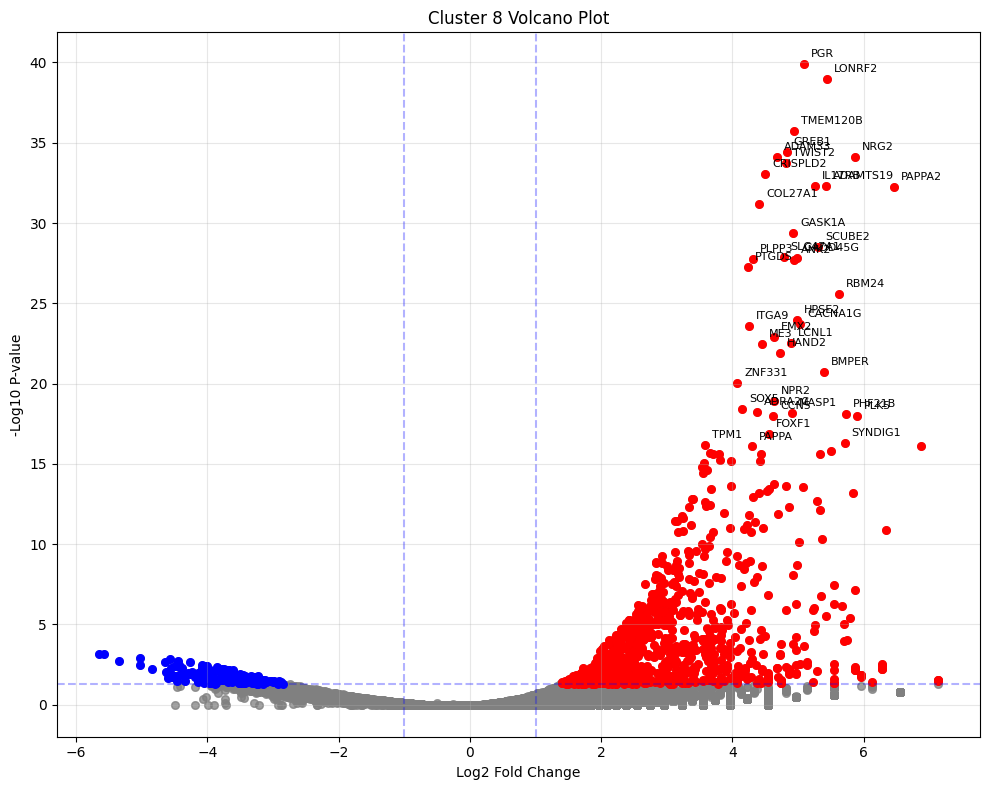

In [13]:
create_volcanoplot('csv files/cluster 8.csv', gene_column="FeatureName", title="Cluster 8 Volcano Plot", log2_fc_threshold=1, p_threshold=0.05,
                       figsize=(10, 8), annotate_top_n=40)

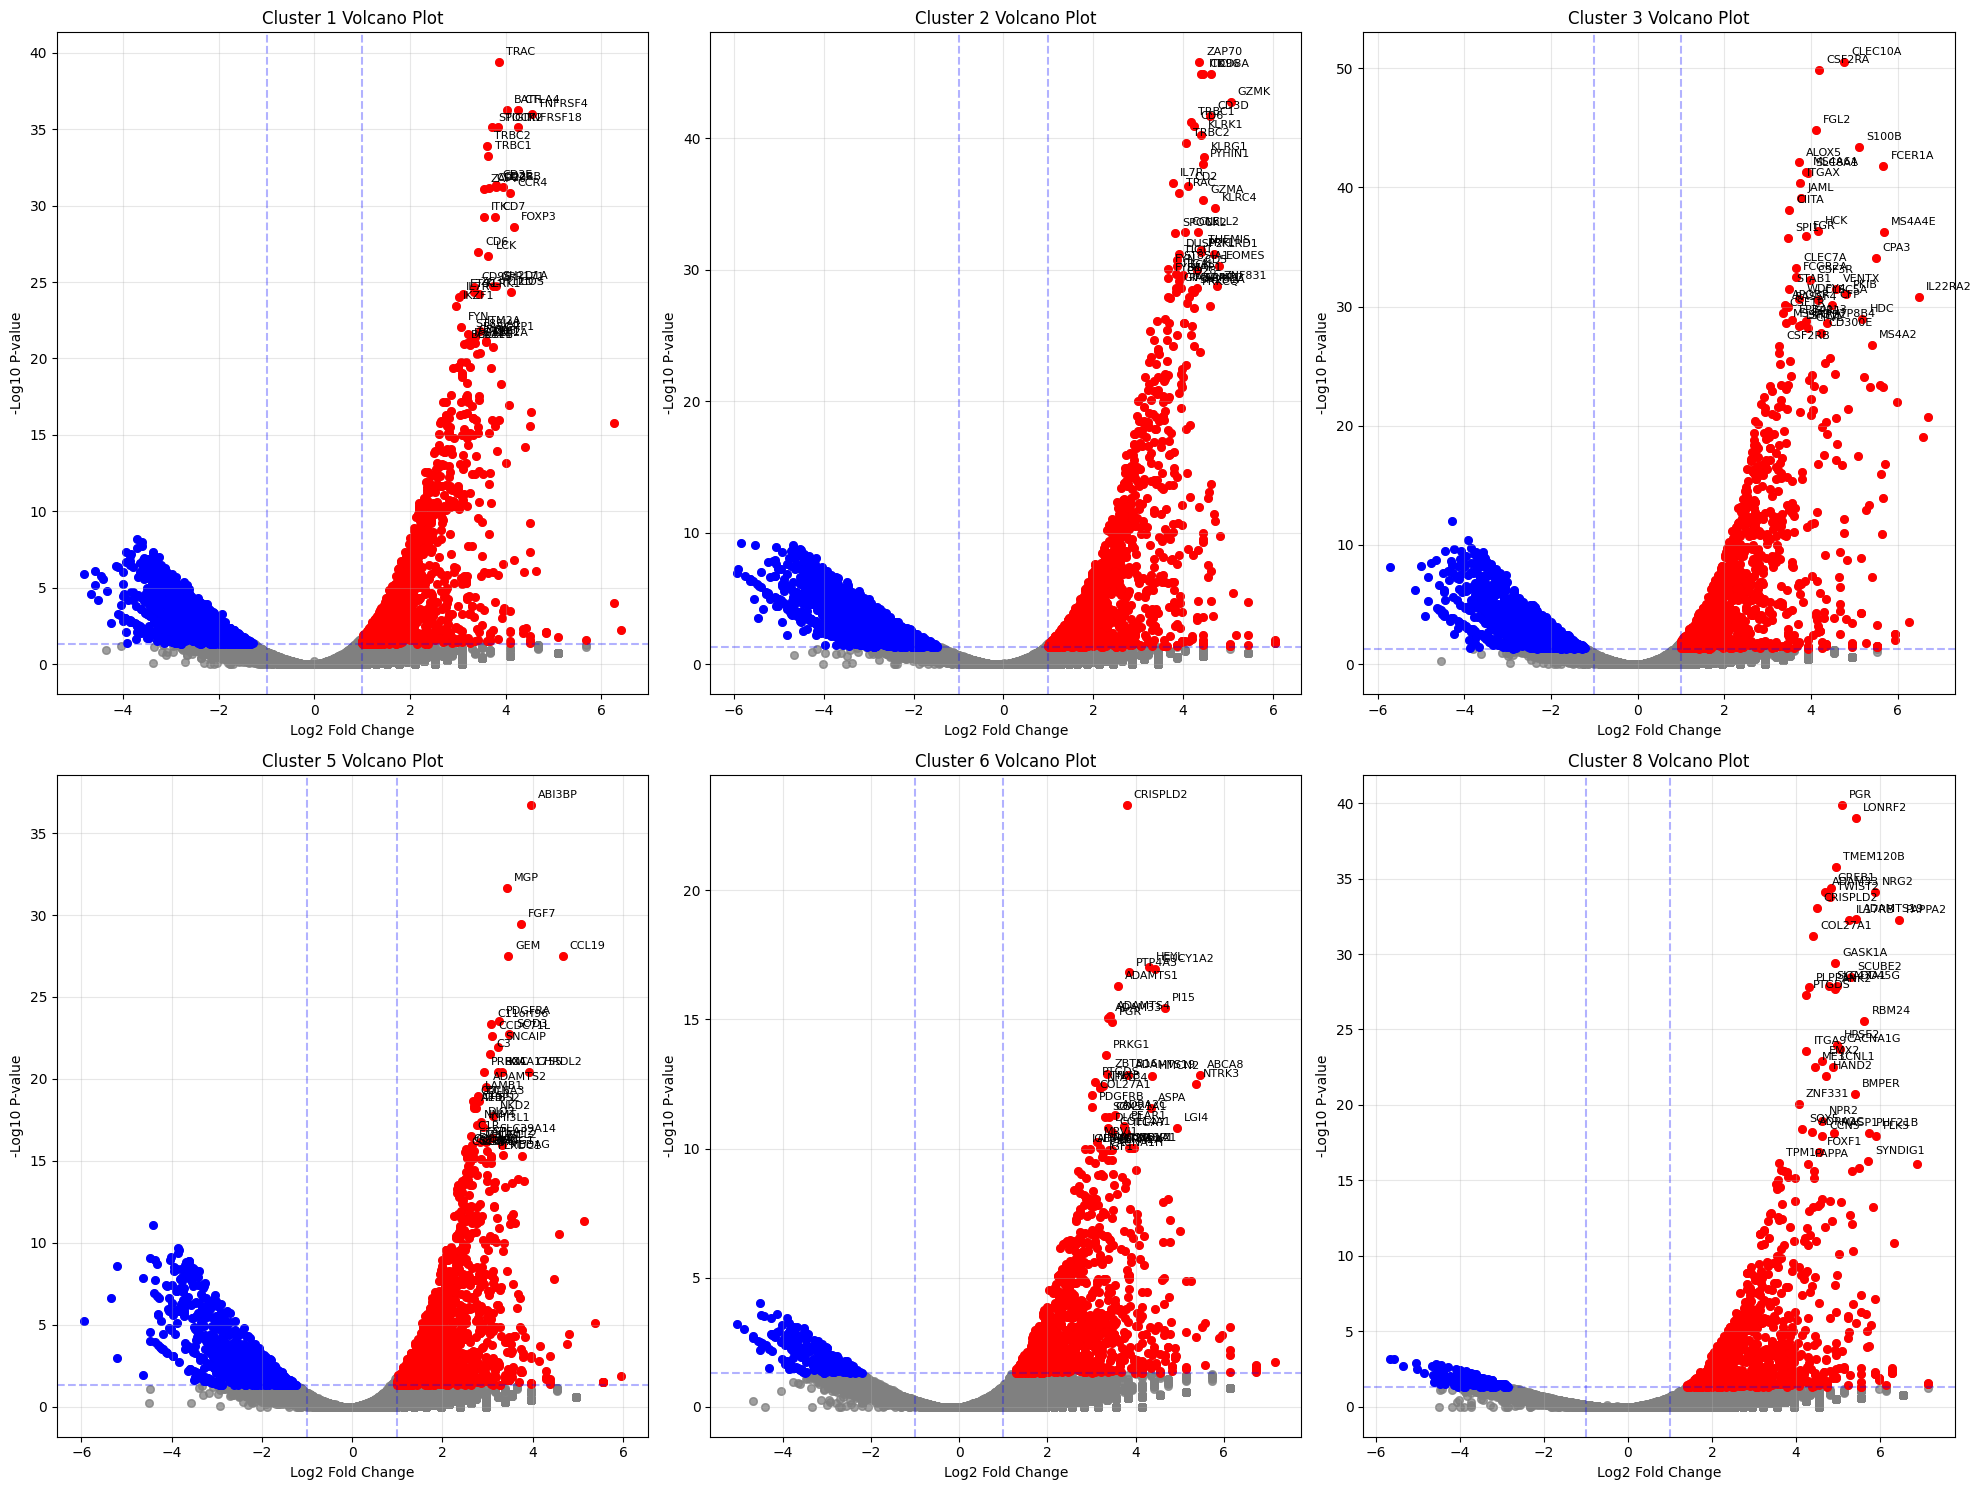

In [66]:
# Plot the individual plots into one multi-panel figure to simplify visualization
### Note: I had help from my CS friend to figure out how to plot on same panel
import matplotlib.pyplot as plt

# I wanted to create a multi-panel figure that I can use for my paper, so I made each volcano plot a subplot.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
axes = axes.flatten()

# This is the list of clusters and their titles to make sure I am using the correct data.
cluster_data = [
    ('csv files/cluster 1.csv', 'Cluster 1 Volcano Plot'),
    ('csv files/cluster 2.csv', 'Cluster 2 Volcano Plot'),
    ('csv files/cluster 3.csv', 'Cluster 3 Volcano Plot'),
    ('csv files/cluster 5.csv', 'Cluster 5 Volcano Plot'),
    ('csv files/cluster 6.csv', 'Cluster 6 Volcano Plot'),
    ('csv files/cluster 8.csv', 'Cluster 8 Volcano Plot')
]

for i, (csv_file, title) in enumerate(cluster_data):
    current_ax = axes[i]
    create_volcanoplot(csv_file, gene_column="FeatureName", title=title, log2_fc_threshold=1, p_threshold=0.05,
                       annotate_top_n=40, ax=current_ax)

plt.tight_layout()
plt.show()

# Training Neural Network and Confusion Matrix for Clusters 1,2,3

The next few codes are for training my model to create a neural network and a confusion matrix for Clusters 1,2,3.

In [67]:
# To train my neural network, I needed to load each cluster to make sure to indicate where the cells belong
c1 = pd.read_csv("csv files/cluster 1.csv")
c1['cluster_label'] = 0
c2 = pd.read_csv("csv files/cluster 2.csv")
c2['cluster_label'] = 1
c3 = pd.read_csv("csv files/cluster 3.csv")
c3['cluster_label'] = 2

In [68]:
df = pd.concat([c1, c2, c3], ignore_index=True)

In [69]:
df = pd.concat([c1, c2, c3], ignore_index=True)

# Defining what I want to classify.
X = df[["Log2 Fold Change", "P-Value"]].copy()
# This is the cluster label.
y = df["cluster_label"]

# This is to make sure that any missing P-Values are accounted for. Had to use Google for this.
X["P-Value"] = np.nan_to_num(X["P-Value"], nan=1.0)

In [70]:
# I kept getting errors because it was recognizing columns that were not numbers, so I plotted the column titles for verification
df.columns

Index(['FeatureID', 'FeatureName', 'Cluster 1 Average', 'Log2 Fold Change',
       'P-Value', 'cluster_label', 'Cluster 2 Average', 'Cluster 3 Average'],
      dtype='object')

In [63]:
# After some research, I figured out that I have to get rid of the columns that are not numbers in order to train neural network.
df = df.drop(columns=["FeatureID"])

In [23]:
df = df.drop(columns=["FeatureName"])

In [72]:
# Normalization of the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
# Train the neural network
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [73]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(y.unique()), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3925 - loss: 1.0835
Epoch 2/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3979 - loss: 1.0800
Epoch 3/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3998 - loss: 1.0772
Epoch 4/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4006 - loss: 1.0725
Epoch 5/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.4024 - loss: 1.0686
Epoch 6/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4088 - loss: 1.0659
Epoch 7/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4141 - loss: 1.0634
Epoch 8/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4146 - loss: 1.0599
Epoch 9/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4194 - loss: 1.0549
Epoch 10/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4218 - loss: 1.0494
Epoch 11/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4247 - loss: 1.0449
Epoch 12/20
1311/1311 ━━━━

# Verification of Neural Network
## To verify that my neural network was accurate, I created a confusion matrix for the clusters below. I was able to compare the True Negatives, False Negatives, True Positives, and False Positives. In addition, PCA plots were created to evaluate the model, but I think the similarities of the cells were too great, and could not really form distinct clusters. However, since the dataset is very large, the confusion matrix was a good way to measure accuracy. 

328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


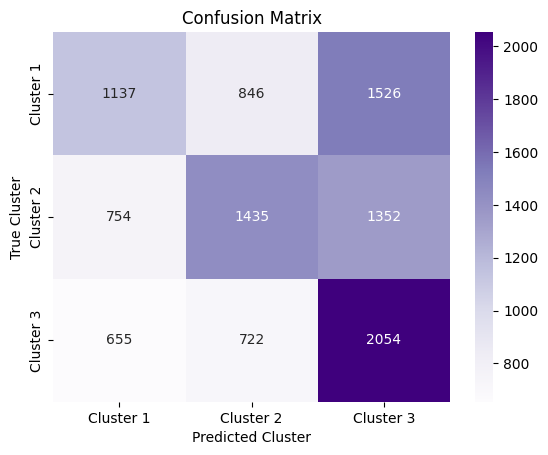

In [76]:
# Create Confusion Matrix for Clusters 1, 2, and 3
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1);

cm = confusion_matrix(y_test, y_pred_classes)

# Define labels for the first confusion matrix
cluster_labels_first_cm = ['Cluster 1', 'Cluster 2', 'Cluster 3']

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=cluster_labels_first_cm,
            yticklabels=cluster_labels_first_cm)
plt.xlabel("Predicted Cluster")
plt.ylabel("True Cluster")
plt.title("Confusion Matrix")
plt.show()

### PCA Plot

To visualize the data, I wanted to use a Principal Component Analysis (PCA) plot. By doing this, I can identify the maximum variance and visualize the data from a different perspective. I made sure to identify each cluster by assigning it a color. I also wanted to identify the genes that are outliers, so I made sure to label them. I used some help from AI to see what was going wrong and editing as I went.

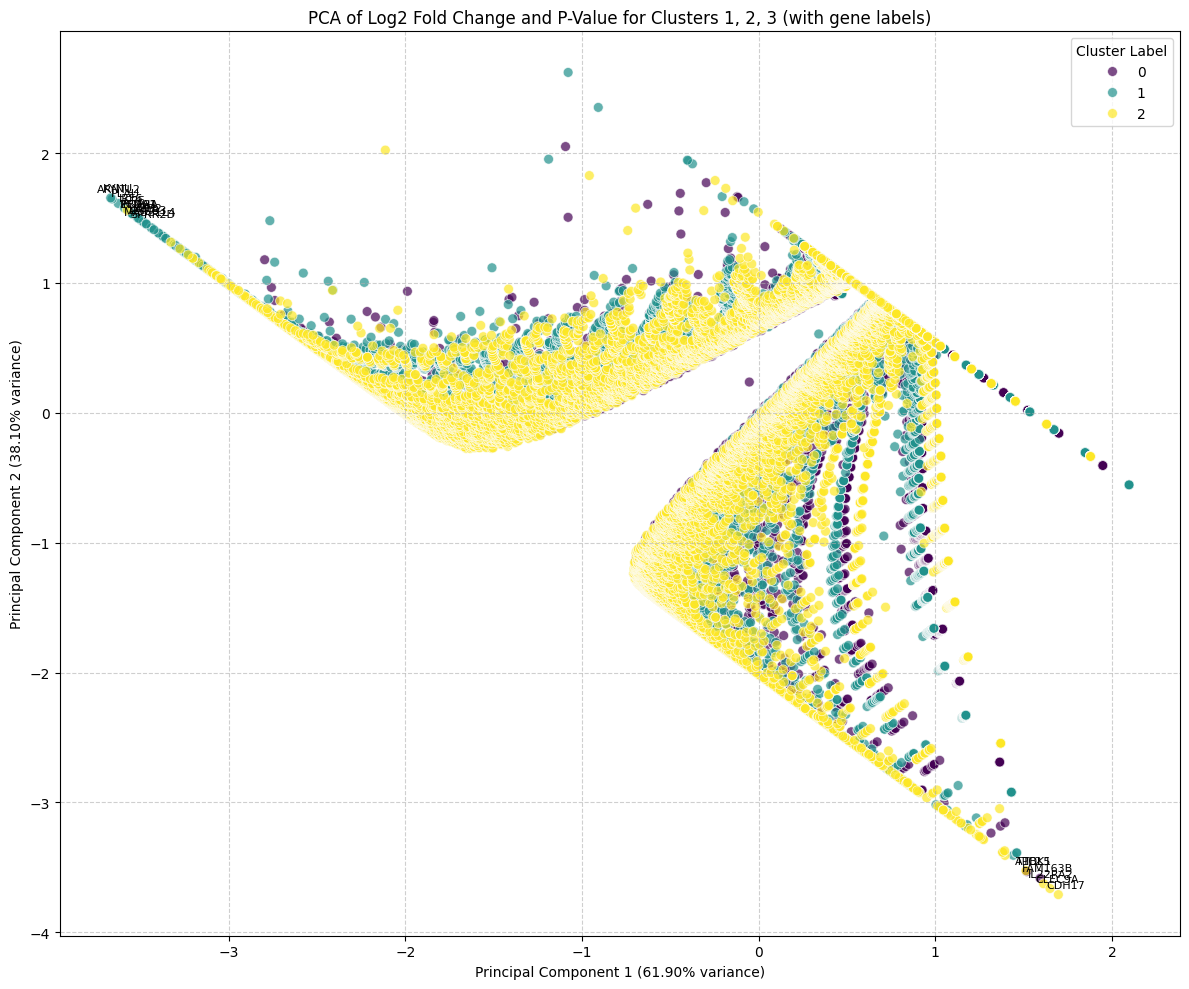

In [77]:
# Re-load data for clusters 1, 2, and 3 to get the 'FeatureName'
c1_annot = pd.read_csv("csv files/cluster 1.csv")
c1_annot['cluster_label'] = 0
c2_annot = pd.read_csv("csv files/cluster 2.csv")
c2_annot['cluster_label'] = 1
c3_annot = pd.read_csv("csv files/cluster 3.csv")
c3_annot['cluster_label'] = 2

# Link the dataframes together
df_annot = pd.concat([c1_annot, c2_annot, c3_annot], ignore_index=True)

# Make sure the features I want are obtained.
X_annot = df_annot[["Log2 Fold Change", "P-Value"]].copy()
y_annot = df_annot["cluster_label"]

X_annot["P-Value"] = np.nan_to_num(X_annot["P-Value"], nan=1.0)

# Features must be scaled
scaler_annot = StandardScaler()
X_scaled_annot = scaler_annot.fit_transform(X_annot)

# Perform PCA
pca_annot = PCA(n_components=2)
pca_components_annot = pca_annot.fit_transform(X_scaled_annot)

# Need a dataframe for plotting the PCA
pca_df_annot = pd.DataFrame(data=pca_components_annot, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_annot['cluster_label'] = y_annot.reset_index(drop=True)
pca_df_annot['FeatureName'] = df_annot['FeatureName'].reset_index(drop=True) # Add FeatureName

# Plot the PCA components
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='cluster_label',
    data=pca_df_annot,
    palette='viridis',
    s=50,
    alpha=0.7
)
plt.title('PCA of Log2 Fold Change and P-Value for Clusters 1, 2, 3 (with gene labels)')
plt.xlabel(f'Principal Component 1 ({pca_annot.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_annot.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster Label')

# AI Generated
# This code labels the top 20 genes. I had to get some help from AI because I was not sure how to plot this, but I made sure to change it within my notebook and not copy it into my code.
annotate_top_n = 20
if annotate_top_n > 0:
    pca_df_annot['magnitude'] = np.sqrt(pca_df_annot['Principal Component 1']**2 + pca_df_annot['Principal Component 2']**2)
    top_n_to_annotate = pca_df_annot.nlargest(annotate_top_n, 'magnitude')

    for i, row in top_n_to_annotate.iterrows():
        if pd.notna(row['FeatureName']):
            plt.annotate(row['FeatureName'],
                         (row['Principal Component 1'], row['Principal Component 2']),
                         textcoords="offset points",
                         xytext=(5,5),
                         ha='center',
                         fontsize=8)

plt.tight_layout()
plt.show()

### Neural Network and Confusion Matrix for Clusters 5, 6, and 8

After creating a confusion matrix for Clusters 1,2,3, I wanted to create one for Clusters 5,6,8. I wanted to make a confusion matrix for both regions.

In [78]:
# Load data for clusters 5, 6, and 8
c5 = pd.read_csv("csv files/cluster 5.csv")
c5['cluster_label'] = 0 # Assign 0-indexed label
c6 = pd.read_csv("csv files/cluster 6.csv")
c6['cluster_label'] = 1 # Assign 0-indexed label
c8 = pd.read_csv("csv files/cluster 8.csv")
c8['cluster_label'] = 2 # Assign 0-indexed label

# Link dataframes together
df_new = pd.concat([c5, c6, c8], ignore_index=True)

# Make sure the features I want are obtained.
X_new = df_new[["Log2 Fold Change", "P-Value"]].copy()
y_new = df_new["cluster_label"]

X_new["P-Value"] = np.nan_to_num(X_new["P-Value"], nan=1.0)

scaler_new = StandardScaler()
X_scaled_new = scaler_new.fit_transform(X_new)

In [79]:
# Split the new data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_scaled_new, y_new, test_size=0.2, random_state=42
)

In [80]:
# Define and train the new neural network model for clusters 5,6,8
model_new = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_new.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(y_new.unique()), activation="softmax")
])

model_new.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Training new model for clusters 5, 6, 8...")
model_new.fit(X_train_new, y_train_new, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training new model for clusters 5, 6, 8...
Epoch 1/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4625 - loss: 1.0007
Epoch 2/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5166 - loss: 0.9277
Epoch 3/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5356 - loss: 0.8936
Epoch 4/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5434 - loss: 0.8778
Epoch 5/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5478 - loss: 0.8680
Epoch 6/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5515 - loss: 0.8617
Epoch 7/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5555 - loss: 0.8565
Epoch 8/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5567 - loss: 0.8515
Epoch 9/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5565 - loss: 0.8480
Epoch 10/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5630 - loss: 0.8441
Epoch 11/20
1311/1311 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5642

328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


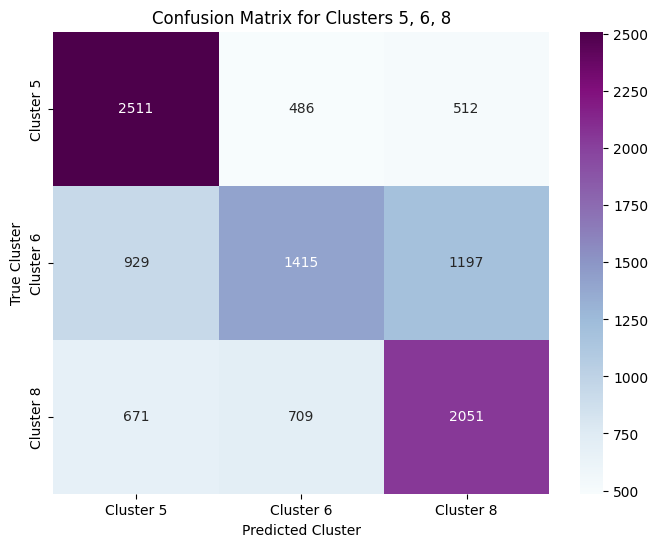

In [84]:
# Create predictions for the new test set
y_pred_new = model_new.predict(X_test_new)
y_pred_classes_new = y_pred_new.argmax(axis=1)

# Create and display the new confusion matrix
cm_new = confusion_matrix(y_test_new, y_pred_classes_new)

# Labeling for the second confusion matrix
cluster_labels_second_cm = ['Cluster 5', 'Cluster 6', 'Cluster 8']

plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt="d", cmap="BuPu",
            xticklabels=cluster_labels_second_cm,
            yticklabels=cluster_labels_second_cm)
plt.xlabel("Predicted Cluster")
plt.ylabel("True Cluster")
plt.title("Confusion Matrix for Clusters 5, 6, 8")
plt.show()

### PCA Plot for Clusters 5, 6, and 8 with gene labels

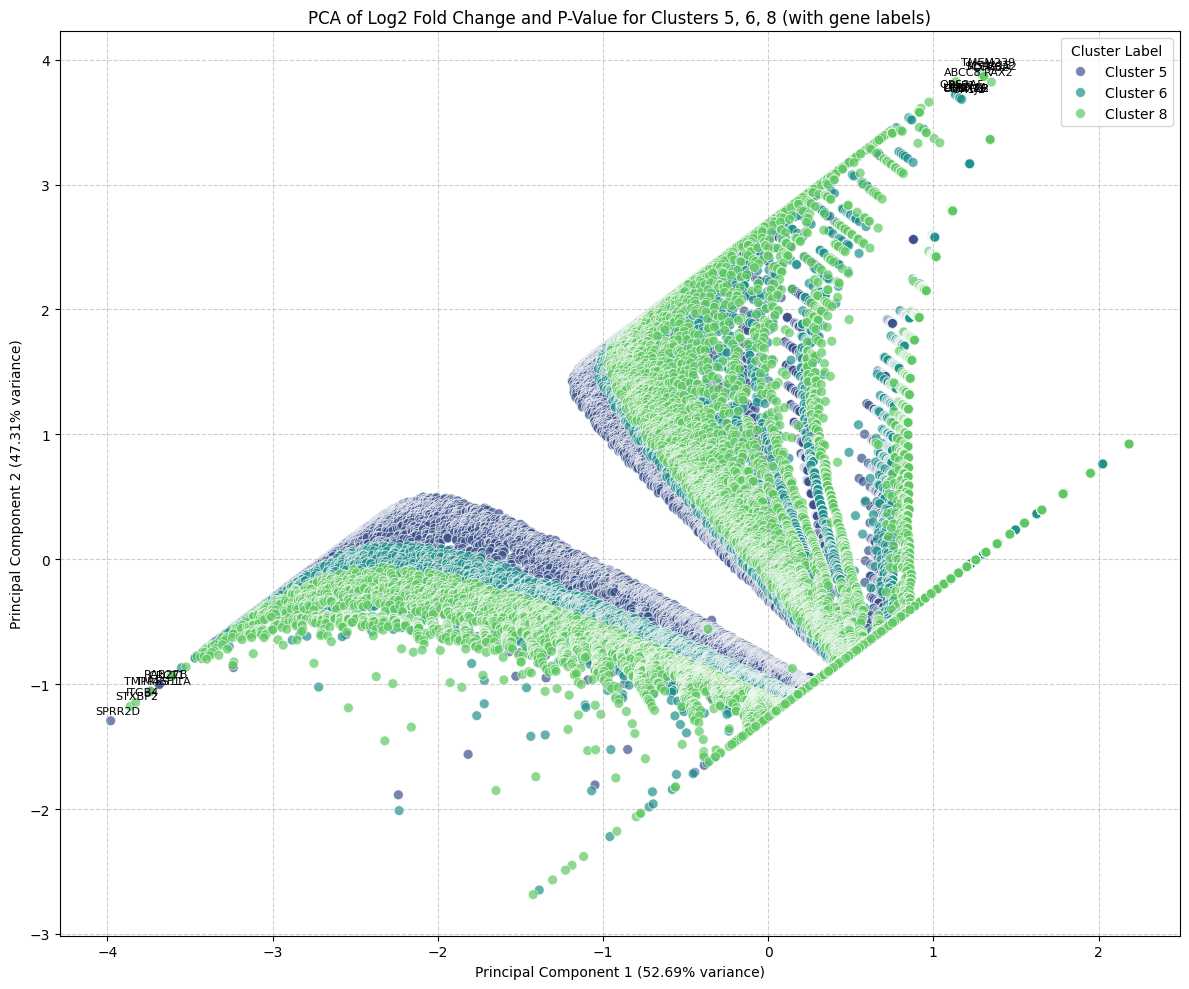

In [86]:
# Re-load data for clusters 5, 6, and 8 to retain 'FeatureName'
c5_annot = pd.read_csv("csv files/cluster 5.csv")
c5_annot['cluster_label'] = 0
c6_annot = pd.read_csv("csv files/cluster 6.csv")
c6_annot['cluster_label'] = 1
c8_annot = pd.read_csv("csv files/cluster 8.csv")
c8_annot['cluster_label'] = 2

# Link the dataframes together
df_annot_568 = pd.concat([c5_annot, c6_annot, c8_annot], ignore_index=True)

# Make sure the features I want are obtained.
X_annot_568 = df_annot_568[["Log2 Fold Change", "P-Value"]].copy()
y_annot_568 = df_annot_568["cluster_label"]

X_annot_568["P-Value"] = np.nan_to_num(X_annot_568["P-Value"], nan=1.0)

# Features must be scaled
scaler_annot_568 = StandardScaler()
X_scaled_annot_568 = scaler_annot_568.fit_transform(X_annot_568)

# Perform PCA
pca_annot_568 = PCA(n_components=2)
pca_components_annot_568 = pca_annot_568.fit_transform(X_scaled_annot_568)

# Need a dataframe for plotting the PCA
pca_df_annot_568 = pd.DataFrame(data=pca_components_annot_568, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_annot_568['cluster_label'] = y_annot_568.reset_index(drop=True)
pca_df_annot_568['FeatureName'] = df_annot_568['FeatureName'].reset_index(drop=True) # Add FeatureName

# Make sure features I wanted are printed
cluster_label_map_568 = {0: 'Cluster 5', 1: 'Cluster 6', 2: 'Cluster 8'}
pca_df_annot_568['cluster_label_name'] = pca_df_annot_568['cluster_label'].map(cluster_label_map_568)

# Plot the PCA components
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='cluster_label_name',
    data=pca_df_annot_568,
    palette='viridis',
    s=50,
    alpha=0.7
)
plt.title('PCA of Log2 Fold Change and P-Value for Clusters 5, 6, 8 (with gene labels)')
plt.xlabel(f'Principal Component 1 ({pca_annot_568.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_annot_568.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster Label')

# Add annotation for the top genes
annotate_top_n_568 = 20
if annotate_top_n_568 > 0:

    pca_df_annot_568['magnitude'] = np.sqrt(pca_df_annot_568['Principal Component 1']**2 + pca_df_annot_568['Principal Component 2']**2)
    # Make sure top genes are the only ones being labeled
    top_n_to_annotate_568 = pca_df_annot_568.nlargest(annotate_top_n_568, 'magnitude')

    for i, row in top_n_to_annotate_568.iterrows():

        if pd.notna(row['FeatureName']):
            plt.annotate(row['FeatureName'],
                         (row['Principal Component 1'], row['Principal Component 2']),
                         textcoords="offset points",
                         xytext=(5,5),
                         ha='center',
                         fontsize=8)

plt.tight_layout()
plt.show()

# Combining all of my data into one PCA plot
I wanted to have a PCA plot that combined all my data together to visualize any similarities or differences. I thought it was good to create one for each region but I wanted one that represented everything as well.

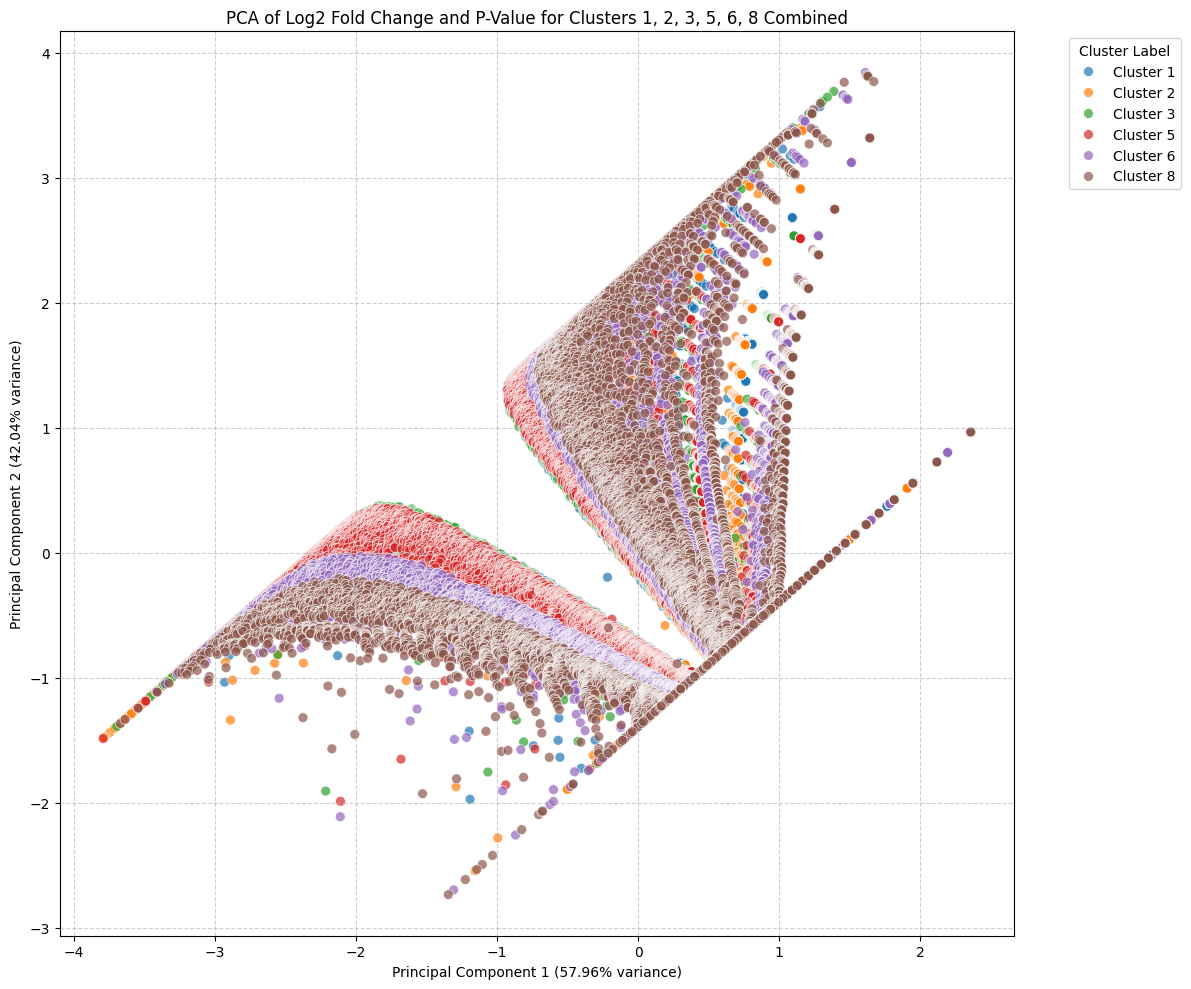

In [87]:
# Reload all of the data to make sure the correct csv files have the correct label
c1_pca = pd.read_csv("csv files/cluster 1.csv")
c1_pca['cluster_label'] = 0
c2_pca = pd.read_csv("csv files/cluster 2.csv")
c2_pca['cluster_label'] = 1
c3_pca = pd.read_csv("csv files/cluster 3.csv")
c3_pca['cluster_label'] = 2
c5_pca = pd.read_csv("csv files/cluster 5.csv")
c5_pca['cluster_label'] = 3
c6_pca = pd.read_csv("csv files/cluster 6.csv")
c6_pca['cluster_label'] = 4
c8_pca = pd.read_csv("csv files/cluster 8.csv")
c8_pca['cluster_label'] = 5

# Link all dataframes
df_combined_pca = pd.concat([c1_pca, c2_pca, c3_pca, c5_pca, c6_pca, c8_pca], ignore_index=True)

# Make sure the features I want are obtained.
X_combined_pca = df_combined_pca[["Log2 Fold Change", "P-Value"]].copy()
y_combined_pca = df_combined_pca["cluster_label"]

X_combined_pca["P-Value"] = np.nan_to_num(X_combined_pca["P-Value"], nan=1.0)

# Features must be scaled
scaler_combined_pca = StandardScaler()
X_scaled_combined_pca = scaler_combined_pca.fit_transform(X_combined_pca)

# Perform PCA
pca_combined = PCA(n_components=2)
pca_components_combined = pca_combined.fit_transform(X_scaled_combined_pca)

# Need a dataframe for plotting the PCA
pca_df_combined = pd.DataFrame(data=pca_components_combined, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_combined['cluster_label'] = y_combined_pca.reset_index(drop=True)


# Make sure features I wanted are printed
cluster_label_map_combined = {
    0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3',
    3: 'Cluster 5', 4: 'Cluster 6', 5: 'Cluster 8'
}
pca_df_combined['cluster_label_name'] = pca_df_combined['cluster_label'].map(cluster_label_map_combined)

# Plot the PCA components
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='cluster_label_name',
    data=pca_df_combined,
    palette='tab10',
    s=50,
    alpha=0.7
)
plt.title('PCA of Log2 Fold Change and P-Value for Clusters 1, 2, 3, 5, 6, 8 Combined')
plt.xlabel(f'Principal Component 1 ({pca_combined.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_combined.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside to avoid overlap
plt.tight_layout()
plt.show()

### Top 20 Genes for Each Cluster

These tables list the top 20 genes that are furthest from the origin in the PCA space for each individual cluster. The genes shown are considered the most 'extreme' and could possibly be the most influential in defining the separation of each respective cluster. I did reference our old lab, but it was not working with my data, so I asked my CS friend for help. We still could not figure it out, so we asked AI for some help. 

In [88]:
# AI Generated
# Reload all of the data to make sure the correct csv files have the correct label
c1_pca_annot = pd.read_csv("csv files/cluster 1.csv")
c1_pca_annot['cluster_label'] = 0
c2_pca_annot = pd.read_csv("csv files/cluster 2.csv")
c2_pca_annot['cluster_label'] = 1
c3_pca_annot = pd.read_csv("csv files/cluster 3.csv")
c3_pca_annot['cluster_label'] = 2
c5_pca_annot = pd.read_csv("csv files/cluster 5.csv")
c5_pca_annot['cluster_label'] = 3
c6_pca_annot = pd.read_csv("csv files/cluster 6.csv")
c6_pca_annot['cluster_label'] = 4
c8_pca_annot = pd.read_csv("csv files/cluster 8.csv")
c8_pca_annot['cluster_label'] = 5

# Link all dataframes
df_combined_pca_annot = pd.concat([c1_pca_annot, c2_pca_annot, c3_pca_annot, c5_pca_annot, c6_pca_annot, c8_pca_annot], ignore_index=True)

# Make sure the features I want are obtained.
X_combined_pca_annot = df_combined_pca_annot[["Log2 Fold Change", "P-Value"]].copy()
y_combined_pca_annot = df_combined_pca_annot["cluster_label"]

X_combined_pca_annot["P-Value"] = np.nan_to_num(X_combined_pca_annot["P-Value"], nan=1.0)

# Features must be scaled
scaler_combined_pca_annot = StandardScaler()
X_scaled_combined_pca_annot = scaler_combined_pca_annot.fit_transform(X_combined_pca_annot)

# Perform PCA
pca_combined_annot = PCA(n_components=2)
pca_components_combined_annot = pca_combined_annot.fit_transform(X_scaled_combined_pca_annot)

# Need a dataframe for plotting the PCA
pca_df_combined_annot = pd.DataFrame(data=pca_components_combined_annot, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_combined_annot['cluster_label'] = y_combined_pca_annot.reset_index(drop=True)
pca_df_combined_annot['FeatureName'] = df_combined_pca_annot['FeatureName'].reset_index(drop=True)

# Make sure features I wanted are printed
cluster_label_map_combined = {
    0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3',
    3: 'Cluster 5', 4: 'Cluster 6', 5: 'Cluster 8'
}
pca_df_combined_annot['cluster_label_name'] = pca_df_combined_annot['cluster_label'].map(cluster_label_map_combined)

# Need to calculate the magnitude to make sure the "extreme" genes are being represented
pca_df_combined_annot['magnitude'] = np.sqrt(pca_df_combined_annot['Principal Component 1']**2 + pca_df_combined_annot['Principal Component 2']**2)

annotate_top_n_per_cluster = 20

for cluster_id, cluster_name in cluster_label_map_combined.items():
    print(f"### Top {annotate_top_n_per_cluster} Genes for {cluster_name}:\n")

    # Filter the data for the recent cluster
    cluster_data = pca_df_combined_annot[pca_df_combined_annot['cluster_label'] == cluster_id]

    # Get the top 20 genes with the largest magnitude for this cluster
    top_genes_for_cluster = cluster_data.nlargest(annotate_top_n_per_cluster, 'magnitude')

    display(top_genes_for_cluster[['FeatureName', 'Principal Component 1', 'Principal Component 2', 'magnitude']])
    print("\n" + "-"*50 + "\n")


### Top 20 Genes for Cluster 1:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
1708,FAM163B,1.288828,3.569019,3.794598
83,TTBK1,1.214926,3.518360,3.722218
749,IL2,1.215116,3.518170,3.722100
418,SLURP2,-3.329129,-1.025699,3.483555
610,PLBD1,-3.270790,-0.967448,3.410868
2436,CYP3A43,1.023364,3.230565,3.388779
385,P3H2,-3.233313,-0.929881,3.364371
514,LYPD2,-3.233015,-0.929605,3.364008
3062,MPPED1,1.079035,3.174894,3.353247
3318,SPATA3,1.105521,3.148408,3.336862



--------------------------------------------------

### Top 20 Genes for Cluster 2:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
17902,KYNU,-3.784395,-1.480961,4.063851
17879,ARNTL2,-3.776813,-1.473379,4.054031
17761,PLAU,-3.743422,-1.439987,4.010832
17934,IRF6,-3.709373,-1.405939,3.966877
17980,PCDH1,-3.667690,-1.364258,3.913202
17972,EFNA1,-3.667151,-1.363717,3.912508
17971,TOP2A,-3.662812,-1.359379,3.906930
17985,YAP1,-3.638931,-1.335498,3.876257
18251,LYPD2,-3.632071,-1.328676,3.867470
17766,LAMB3,-3.619341,-1.315906,3.851135



--------------------------------------------------

### Top 20 Genes for Cluster 3:



...


--------------------------------------------------

### Top 20 Genes for Cluster 6:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
70800,TMEM239,1.610735,3.842978,4.166886
70859,OR52A5,1.450260,3.663342,3.939966
70885,PLP1,1.453505,3.660098,3.938146
70985,LRRTM4,1.466494,3.647109,3.930904
71023,DUXA,1.473027,3.640575,3.927289
71051,DMRTC2,1.476562,3.637041,3.925341
71061,PHOX2B,1.477903,3.635700,3.924603
71117,OR1J1,1.487284,3.626319,3.919465
70285,ZNF536,1.166992,3.467254,3.658377
70571,MEOX2,1.177673,3.456572,3.651685



--------------------------------------------------

### Top 20 Genes for Cluster 8:



,FeatureName,Principal Component 1,Principal Component 2,magnitude
88233,MS4A13,1.619034,3.821563,4.150375
88275,SCGB3A2,1.625073,3.815524,4.147178
88302,CTRB2,1.629144,3.811453,4.145031
88540,RAX2,1.670432,3.770165,4.123650
87380,ABCC8,1.460807,3.764242,4.037756
87761,STXBP2,-3.668491,-1.367496,3.915082
87771,ITGB4,-3.634773,-1.333993,3.871836
87350,PAPPA2,1.292327,3.595761,3.820943
87426,GATA5,1.242242,3.545677,3.756992
87827,TM4SF1,-3.541302,-1.244866,3.753733



--------------------------------------------------

